In [2]:
import subprocess, shutil, sys, os

rsvg  = shutil.which("rsvg-convert")
ink   = shutil.which("inkscape")
conv  = shutil.which("convert")
print(f"rsvg-convert : {rsvg or 'not found'}")
print(f"inkscape     : {ink  or 'not found'}")
print(f"convert (IM) : {conv or 'not found'}")


rsvg-convert : not found
inkscape     : not found
convert (IM) : not found


In [9]:
SVG     = "/workspaces/Bloxel-wasm/static/icon.svg"
OUT_192 = "/workspaces/Bloxel-wasm/static/icon-192.png"
OUT_512 = "/workspaces/Bloxel-wasm/static/icon-512.png"
SIZES   = [(192, OUT_192), (512, OUT_512)]

assert os.path.exists(SVG), f"SVG not found: {SVG}"
print("SVG source confirmed:", SVG)

tool_used = None


SVG source confirmed: /workspaces/Bloxel-wasm/static/icon.svg


In [10]:
if rsvg and tool_used is None:
    ok = True
    for size, out in SIZES:
        r = subprocess.run([rsvg, "-w", str(size), "-h", str(size), SVG, "-o", out],
                           capture_output=True, text=True)
        print(f"rsvg-convert {size}x{size}: returncode={r.returncode}")
        if r.stdout: print("stdout:", r.stdout)
        if r.stderr: print("stderr:", r.stderr)
        if r.returncode != 0:
            ok = False; break
    if ok:
        tool_used = "rsvg-convert"
        print("rsvg-convert succeeded.")


In [11]:
if ink and tool_used is None:
    ok = True
    for size, out in SIZES:
        r = subprocess.run([ink, "--export-type=png",
                            f"--export-width={size}", f"--export-filename={out}", SVG],
                           capture_output=True, text=True)
        print(f"inkscape {size}x{size}: returncode={r.returncode}")
        if r.stdout: print("stdout:", r.stdout)
        if r.stderr: print("stderr:", r.stderr)
        if r.returncode != 0:
            ok = False; break
    if ok:
        tool_used = "inkscape"
        print("inkscape succeeded.")


In [12]:
if tool_used is None:
    try:
        try:
            import cairosvg
        except ImportError:
            print("Installing cairosvg...")
            subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "cairosvg"], check=True)
            import cairosvg
        for size, out in SIZES:
            cairosvg.svg2png(url=SVG, write_to=out, output_width=size, output_height=size)
            print(f"cairosvg wrote {out}")
        tool_used = "cairosvg"
        print("cairosvg succeeded.")
    except Exception as e:
        print(f"cairosvg failed: {e}")


cairosvg wrote /workspaces/Bloxel-wasm/static/icon-192.png
cairosvg wrote /workspaces/Bloxel-wasm/static/icon-512.png
cairosvg succeeded.


In [7]:
if tool_used is None:
    import zlib, struct, math

    def write_png(size, out_path):
        W = H = size
        s = size / 512.0
        px = bytearray(W * H * 4)

        def set_px(x, y, r, g, b, a=255):
            if 0 <= x < W and 0 <= y < H:
                i = (y * W + x) * 4
                px[i], px[i+1], px[i+2], px[i+3] = r, g, b, a

        def fill_rect(fx, fy, fw, fh, r, g, b, rx_=0):
            for py in range(max(0, int(fy)), min(H, math.ceil(fy + fh))):
                for px_ in range(max(0, int(fx)), min(W, math.ceil(fx + fw))):
                    if rx_ > 0:
                        dx = min(px_ - fx, fx + fw - 1 - px_)
                        dy = min(py - fy, fy + fh - 1 - py)
                        if dx < rx_ and dy < rx_ and (dx-rx_)**2+(dy-rx_)**2 > rx_**2:
                            continue
                    set_px(px_, py, r, g, b)

        # Fill entire canvas with outer dark color
        for i in range(W * H):
            px[i*4], px[i*4+1], px[i*4+2], px[i*4+3] = 10, 4, 22, 255

        # Outer rounded rect dark
        outer_rx = int(112 * s)
        fill_rect(0, 0, W, H, 10, 4, 22, rx_=outer_rx)

        # Inner gradient rect
        inner_x, inner_y = int(16*s), int(16*s)
        inner_w, inner_h = int(480*s), int(480*s)
        inner_rx = int(96 * s)
        for py in range(inner_y, inner_y + inner_h):
            t = (py - inner_y) / max(inner_h - 1, 1)
            rc = int(0x8b + (0x3b - 0x8b) * t)
            gc = int(0x5c + (0x07 - 0x5c) * t)
            bc = int(0xf6 + (0x64 - 0xf6) * t)
            for px_ in range(inner_x, inner_x + inner_w):
                dx = min(px_ - inner_x, inner_x + inner_w - 1 - px_)
                dy = min(py - inner_y, inner_y + inner_h - 1 - py)
                if dx < inner_rx and dy < inner_rx and (dx-inner_rx)**2+(dy-inner_rx)**2 > inner_rx**2:
                    continue
                set_px(px_, py, rc, gc, bc)

        # White blocks (the B letterform)
        blocks = [
            (119,63),(175,63),(231,63),(287,63),
            (119,119),(287,119),
            (119,175),(287,175),
            (119,231),(175,231),(231,231),(287,231),
            (119,287),(343,287),
            (119,343),(343,343),
            (119,399),(175,399),(231,399),(287,399),(343,399),
        ]
        for bx, by in blocks:
            fill_rect(bx*s, by*s, 50*s, 50*s, 255, 255, 255, rx_=int(5*s))

        # Encode PNG
        def make_chunk(tag, data):
            c = zlib.crc32(tag + data) & 0xffffffff
            return struct.pack(">I", len(data)) + tag + data + struct.pack(">I", c)

        ihdr = struct.pack(">IIBBBBB", W, H, 8, 2, 0, 0, 0)
        raw = b"".join(b"\x00" + bytes(px[r*W*4:(r+1)*W*4]) for r in range(H))
        idat = zlib.compress(raw, 6)
        data = (b"\x89PNG\r\n\x1a\n" + make_chunk(b"IHDR", ihdr) +
                make_chunk(b"IDAT", idat) + make_chunk(b"IEND", b""))
        with open(out_path, "wb") as f:
            f.write(data)
        print(f"pure-python wrote {out_path} ({len(data)} bytes)")

    for size, out in SIZES:
        write_png(size, out)
    tool_used = "pure-python"
    print("pure-python fallback succeeded.")



=== Result ===
Tool used: cairosvg
  /workspaces/Bloxel-wasm/static/icon-192.png: 20,994 bytes  OK
  /workspaces/Bloxel-wasm/static/icon-512.png: 80,053 bytes  OK


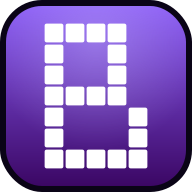

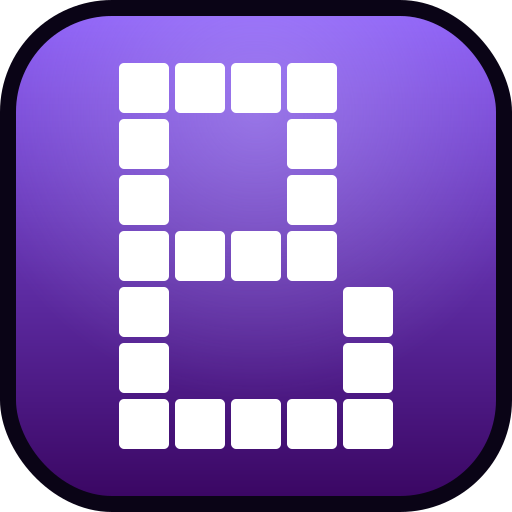

In [13]:
print(f"\n=== Result ===")
print(f"Tool used: {tool_used}")
for _, out in SIZES:
    if os.path.exists(out):
        print(f"  {out}: {os.path.getsize(out):,} bytes  OK")
    else:
        print(f"  {out}: MISSING")

from IPython.display import Image, display
for _, out in SIZES:
    if os.path.exists(out):
        display(Image(filename=out))
